#### **Mental Health Dataset - Tech Challenge - PosTech FIAP AI4DEVS 9IADT - Grupo 20**

###### O conjunto de dados reúne características de análise de texto, sentimento e aspectos psicológicos, incluindo índices de legibilidade e indicadores como estresse, isolamento e uso de substâncias.

###### https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset

#### **Importar Bibliotecas**

###### Nesta seção, são importadas as bibliotecas necessárias para a realização da análise de dados e para o desenvolvimento do modelo.

In [2]:
#Interagir com o sistema operacional.
import os

#Mostrar barras de progresso em loops e processos demorados.
from tqdm import tqdm

#pip install kagglehub
#Baixar e acessar datasets e modelos do Kaggle diretamente no Python
import kagglehub

#pip install pandas
#Trabalhar com dados estruturados (tabelas)
import pandas as pd

#pip install numpy
#Trabalhar com arrays (vetores e matrizes) de forma rápida e eficiente.
import numpy as np

#pip install matplotlib
#Criar gráficos e plots (visualizações) de forma totalmente personalizada.
import matplotlib.pyplot as plt

##pip install seaborn
#Criar gráficos estatísticos mais bonitos, simples e informativos.
import seaborn as sns

#Encadear várias etapas de processamento e modelagem em um único fluxo organizado.
from sklearn.pipeline import Pipeline

#Converter variáveis categóricas em números inteiros mantendo uma ordem.
from sklearn.preprocessing import OrdinalEncoder

#Transformar variáveis categóricas em várias colunas binárias (0 ou 1)
from sklearn.preprocessing import OneHotEncoder

#Preencher valores ausentes (missing values) em um dataset.
from sklearn.impute import SimpleImputer

#Aplicar diferentes transformações em diferentes colunas do dataset.
from sklearn.compose import ColumnTransformer

#Padronizar os dados numéricos para terem média 0 e desvio padrão 1.
from sklearn.preprocessing import StandardScaler

#Dividir os dados em conjuntos de treino e teste.
from sklearn.model_selection import train_test_split

#Validação cruzada e estratégia de divisão KFold.
from sklearn.model_selection import cross_validate, KFold

#Classificar um dado com base nos seus vizinhos mais próximos.
from sklearn.neighbors import KNeighborsClassifier

#Realizar classificação (principalmente binária) usando um modelo linear.
from sklearn.linear_model import LogisticRegression

#Criar um modelo de classificação baseado em várias árvores de decisão.
from sklearn.ensemble import RandomForestClassifier

#Classificar dados usando o algoritmo de Máquina de Vetores de Suporte (SVM).
from sklearn.svm import SVC

#Criar uma cópia de um modelo sem copiar o treinamento (parâmetros aprendidos).
from sklearn.base import clone

#Calcula os pontos da curva ROC / Calcula a área sob a curva ROC
from sklearn.metrics import roc_curve, auc

#Relatório completo de avaliação
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, make_scorer, f1_score, ConfusionMatrixDisplay, roc_curve,precision_recall_curve, average_precision_score, auc


#### **Importar Datasets**

###### Nesta seção, realizamos o download do dataset diretamente do Kaggle utilizando a classe kagglehub e, em seguida, o convertemos em um DataFrame para ser manipulado com o pandas.

In [3]:
# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/mental-health-dataset")

file_path = os.path.join(path, "Mental Health Dataset.csv")
#print(file_path)

df = pd.read_csv(file_path)

### **Análise exploratória dos dados**

###### Nesta seção, iniciamos a análise exploratória dos dados utilizando métodos do pandas, como head(), shape e info().

In [4]:
#Retorna numero de linhas e colunas do dataframe
df.shape

(292364, 17)

In [5]:
#Mostrar linhas dataframe
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [6]:
#Resumo geral do dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Timestamp                292364 non-null  str  
 1   Gender                   292364 non-null  str  
 2   Country                  292364 non-null  str  
 3   Occupation               292364 non-null  str  
 4   self_employed            287162 non-null  str  
 5   family_history           292364 non-null  str  
 6   treatment                292364 non-null  str  
 7   Days_Indoors             292364 non-null  str  
 8   Growing_Stress           292364 non-null  str  
 9   Changes_Habits           292364 non-null  str  
 10  Mental_Health_History    292364 non-null  str  
 11  Mood_Swings              292364 non-null  str  
 12  Coping_Struggles         292364 non-null  str  
 13  Work_Interest            292364 non-null  str  
 14  Social_Weakness          292364 non-null  str  

### **Análise da Qualidade dos Dados**

###### Nesta seção começaremos a verificar a existência de dados não representativos, viês de amostragem, discrepancia em variáveis e/ou possíveis deficiências.

In [7]:
#Retorna os valores nulos de cada coluna
df.isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

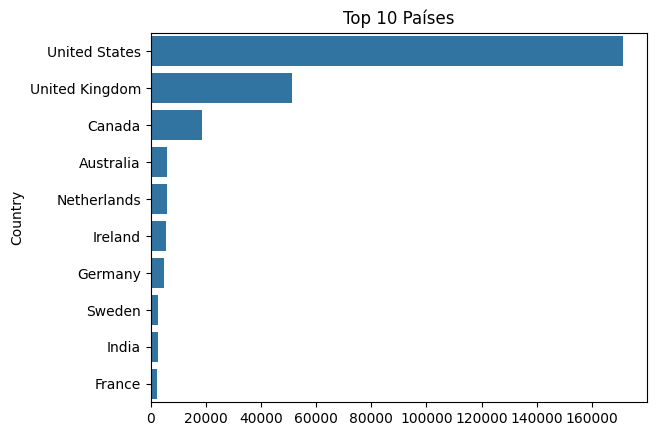

In [8]:
top_countries = df['Country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Países')
plt.show()

<span style="font-size: 12px;">
Os dados esta fortemente direcionado para EUA, mas pela caracteristica das variaveis entendemos que podemos remover esta coluna, pois entendemos que não seria o caso de derecionar a predição para determinados paises.
</span>

In [9]:
df_temp = df[['care_options', 'mental_health_interview','self_employed','Growing_Stress',
              'Changes_Habits','Coping_Struggles','Work_Interest','Social_Weakness','treatment']].copy()

variaveis = ['self_employed','care_options','Growing_Stress','Changes_Habits','Coping_Struggles','Work_Interest','Social_Weakness', 'mental_health_interview']

df_temp[variaveis + ['treatment']] = df_temp[variaveis + ['treatment']].replace({
    'Yes': 1, 'No': 0,
    'yes': 1, 'no': 0,
    True: 1, False: 0
})

<span style="font-size: 12px;">
Centralizamos algumas variaveis para realizar uma análise de correlação com a nossa taget
</span>

<Axes: >

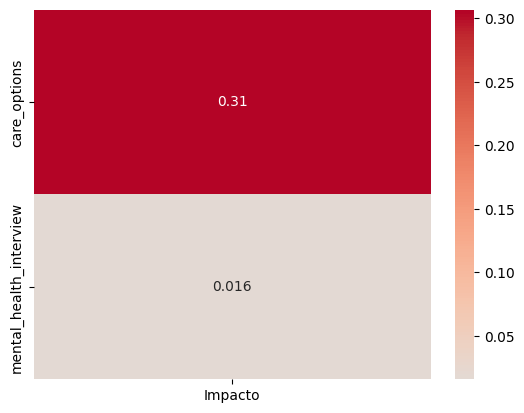

In [10]:
variaveis = ['care_options', 'mental_health_interview']
diffs = []

for var in variaveis:
    ct = pd.crosstab(df_temp[var], df_temp['treatment'], normalize='index')

    p0 = ct.loc[0, 1] if 0 in ct.index else 0
    p1 = ct.loc[1, 1] if 1 in ct.index else 0

    diffs.append(p1 - p0)

heatmap_df = pd.DataFrame(diffs, index=variaveis, columns=['Impacto'])

sns.heatmap(heatmap_df, annot=True, cmap='coolwarm', center=0)

<span style="font-size: 12px;">
Aqui podemos observar que estas variáveis apresentam discrepancia com a nossa target, possívelmente uma vies de amostragem. </br>
Não tem sentido que uma pessoa que toma cuidados seja mais apto de precisar tratamento que uma outra pessoa que não toma cuidados.</br> </br>
Para a outra variável decidimos tentar entender melhor a intenção do dado, e verificando no link do dataset obtemos a seguinte informação sobre ela (mental_health_interview)
</span>

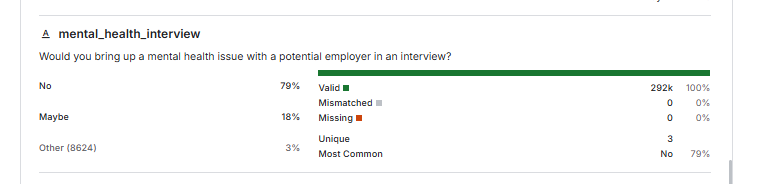

<Axes: xlabel='treatment', ylabel='Occupation'>

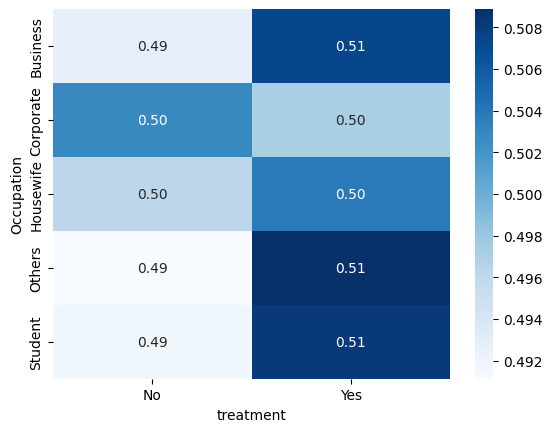

In [11]:
import seaborn as sns

ct = pd.crosstab(df['Occupation'], df['treatment'], normalize='index')

sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")

<span style="font-size: 12px;">
Observamos aqui que a variável Ocupation não tem representatividade para nossa target, tanto assim que todas apresentam o mesmo valor de influencia. </br>
Também não encontramos muito sentido como estas profissões podem influenciar no tratamento, acreditamos que seja um dado coletado de identificação apenas.

In [12]:
#Apresentacao dos valores unicos de cada coluna
for col in df.columns:
    print(f"{col:30s} → {df[col].unique().tolist()}")

Timestamp                      → ['8/27/2014 11:29', '8/27/2014 11:31', '8/27/2014 11:32', '8/27/2014 11:37', '8/27/2014 11:43', '8/27/2014 11:49', '8/27/2014 11:51', '8/27/2014 11:52', '8/27/2014 12:18', '8/27/2014 12:37', '8/27/2014 12:39', '8/27/2014 12:40', '8/27/2014 12:49', '8/27/2014 12:50', '8/27/2014 12:51', '8/27/2014 12:53', '8/27/2014 12:55', '8/27/2014 12:57', '8/27/2014 13:06', '8/27/2014 13:31', '8/27/2014 13:47', '8/27/2014 13:49', '8/27/2014 13:55', '8/27/2014 14:11', '8/27/2014 14:13', '8/27/2014 14:16', '8/27/2014 14:19', '8/27/2014 14:27', '8/27/2014 14:31', '8/27/2014 14:52', '8/27/2014 15:22', '8/27/2014 15:24', '8/27/2014 15:29', '8/27/2014 15:34', '8/27/2014 15:35', '8/27/2014 15:36', '8/27/2014 16:02', '8/27/2014 16:14', '8/27/2014 16:19', '8/27/2014 16:21', '8/27/2014 16:25', '8/27/2014 16:27', '8/27/2014 16:35', '8/27/2014 16:42', '8/27/2014 17:08', '8/27/2014 17:32', '8/27/2014 17:37', '8/27/2014 17:48', '8/27/2014 17:56', '8/27/2014 18:02', '8/27/2014 18:59

<span style="font-size: 12px;">
Olhando os valores de cada coluna, vemos que muitas delas apresentam a opção 'Maybe', não deixando clara a categoria da variável. </br>
Aqui optamos por remover as linhas que ficaram nesse cenário para deixar a predição mais direta para as categorias 'Yes' e 'No'.
</span>

In [13]:
ct = pd.crosstab(df['Social_Weakness'], df['treatment'], normalize='columns') * 100
print(ct)

treatment               No        Yes
Social_Weakness                      
Maybe            35.470233  35.260762
No               33.216126  33.386854
Yes              31.313641  31.352384


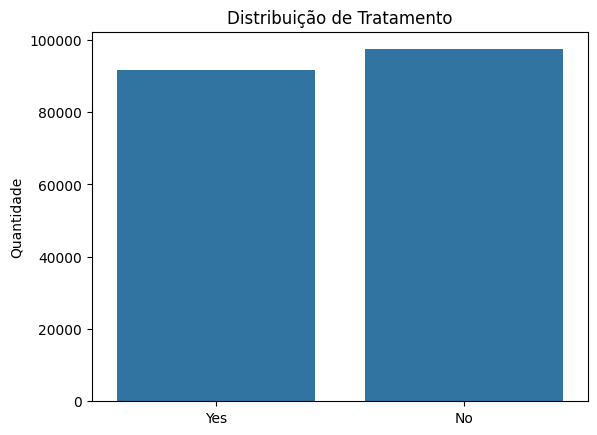

In [14]:
sns.countplot(data=df, x='Social_Weakness', order=['Yes', 'No'])
plt.title('Distribuição de Tratamento')
plt.ylabel('Quantidade')
plt.xlabel('')
plt.show()

In [15]:
ct = pd.crosstab(df['Social_Weakness'], df['treatment'], normalize='columns') * 100
print(ct)

treatment               No        Yes
Social_Weakness                      
Maybe            35.470233  35.260762
No               33.216126  33.386854
Yes              31.313641  31.352384


In [16]:
df['self_employed'] = df.groupby('treatment')['self_employed']\
               .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

In [17]:
df['Growing_Stress'] = df.groupby('treatment')['Growing_Stress']\
               .transform(lambda x: x.mask(x == 'Maybe',
                                            x.mode()[0] if not x.mode().empty else x))

In [18]:
df['Changes_Habits'] = df.groupby('treatment')['Changes_Habits']\
               .transform(lambda x: x.mask(x == 'Maybe',
                                            x.mode()[0] if not x.mode().empty else x))

In [19]:
df['Work_Interest'] = df.groupby('treatment')['Work_Interest']\
               .transform(lambda x: x.mask(x == 'Maybe',
                                            x.mode()[0] if not x.mode().empty else x))

In [20]:
df['Social_Weakness'] = df.groupby('treatment')['Social_Weakness']\
               .transform(lambda x: x.mask(x == 'Maybe',
                                            x.mode()[0] if not x.mode().empty else x))

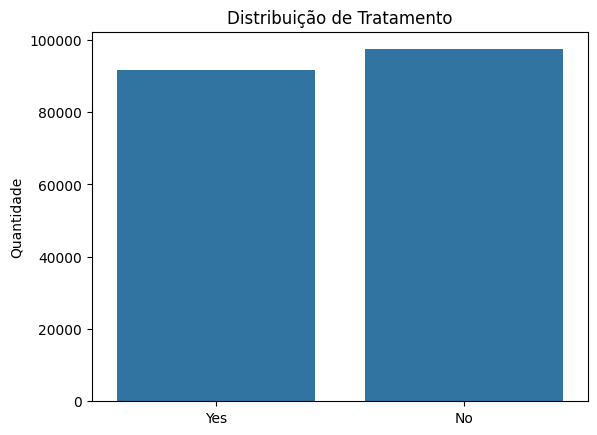

In [21]:
sns.countplot(data=df, x='Social_Weakness', order=['Yes', 'No'])
plt.title('Distribuição de Tratamento')
plt.ylabel('Quantidade')
plt.xlabel('')
plt.show()

In [22]:
def remove_values(df, conditions):
    mask = pd.Series(True, index=df.index)

    for col, val in conditions.items():
        mask &= df[col] != val

    return df[mask]

conditions = {
    'Growing_Stress': 'Maybe',
    'Changes_Habits': 'Maybe',
    'Mental_Health_History': 'Maybe',
    'Work_Interest': 'Maybe',
    'Social_Weakness': 'Maybe'
}

df = remove_values(df, conditions)

<span style="font-size: 12px;">
Remoção da linhas com valor nulo.
Obtamos por não preencher estes valores com as tecnicas existentes pois para esta situação entendemos que iremos distorcer o resultado.
</span>

In [23]:
df = df[df['self_employed'].notna()]

In [24]:
#Removendo as colunas que não vemos relevantes para o nosso estudo
df = df.drop(['Timestamp'], axis=1)
df = df.drop(['Country'], axis=1)
df = df.drop(['care_options'], axis=1)
df = df.drop(['mental_health_interview'], axis=1)
df = df.drop(['Occupation'], axis=1)

### **Plotagem dos Dados Significativos**

###### Nesta seção, iniciamos a visualização dos dados com o auxílio das bibliotecas matplotlib e seaborn, a fim de facilitar a compreensão e interpretação das informações.

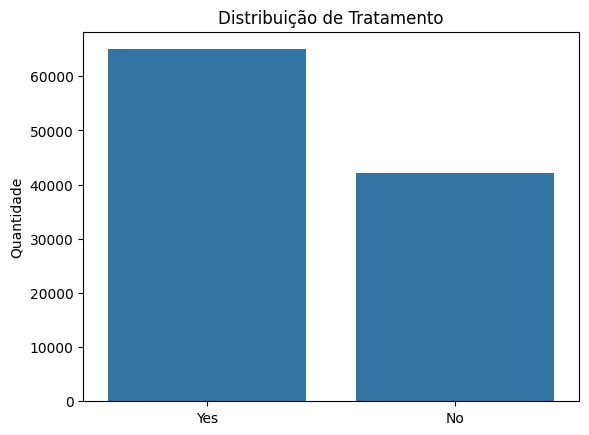

In [25]:
sns.countplot(data=df, x='treatment', order=['Yes', 'No'])
plt.title('Distribuição de Tratamento')
plt.ylabel('Quantidade')
plt.xlabel('')
plt.show()

<span style="font-size: 12px;">
<b>Distribuição praticamente equilibrada</b><br>
</span>

<Axes: >

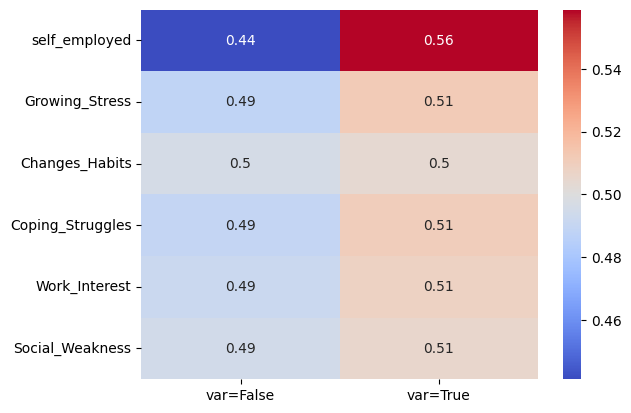

In [26]:
rows = []

variaveis = ['self_employed','Growing_Stress','Changes_Habits','Coping_Struggles','Work_Interest','Social_Weakness']

for var in variaveis:
    ct = pd.crosstab(df_temp[var], df_temp['treatment'], normalize='index')

    p0 = ct.loc[1, 0] if 1 in ct.index else 0
    p1 = ct.loc[1, 1] if 1 in ct.index else 0

    rows.append([p0, p1])

heatmap_df = pd.DataFrame(rows, index=variaveis, columns=['var=False', 'var=True'])

sns.heatmap(heatmap_df, annot=True, cmap='coolwarm')

<span style="font-size: 12px;">
Pode-se observar que todas estas variáveis não apresentam relevância para nossa variável, mas decidimos em mante-las por serem caracteristicas importantes.
</span>

<Axes: xlabel='treatment', ylabel='Mood_Swings'>

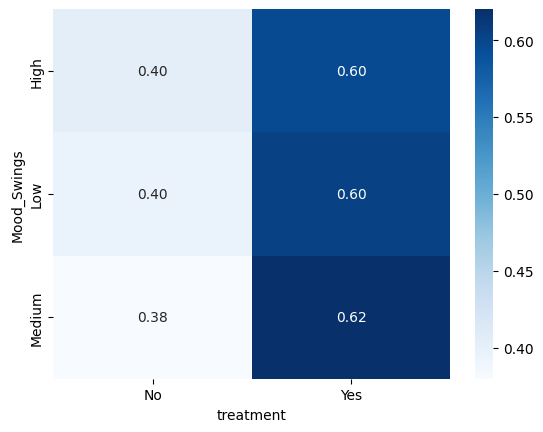

In [27]:
import seaborn as sns

ct = pd.crosstab(df['Mood_Swings'], df['treatment'], normalize='index')

sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")

<span style="font-size: 12px;">
Podemos observar aqui que o nível de mudança de humor é um leve diferencial para procurar de um tratamento.
</span>

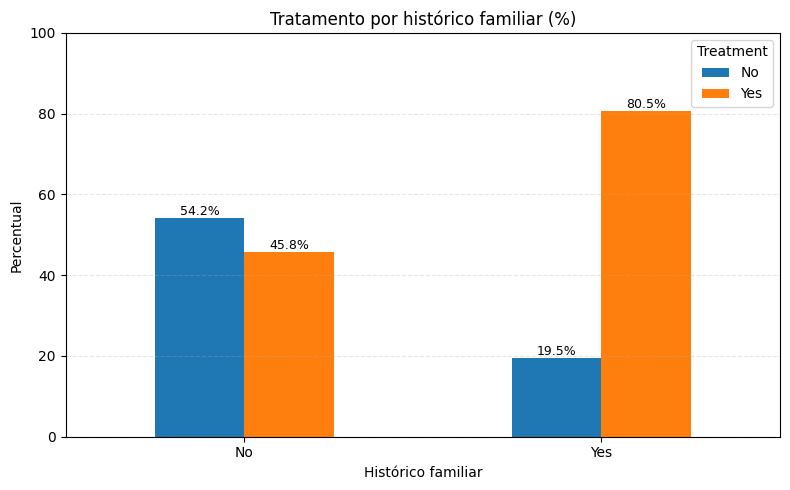

In [28]:
ct = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100

ax = ct.plot(kind='bar', figsize=(8,5))

plt.title('Tratamento por histórico familiar (%)')
plt.ylabel('Percentual')
plt.xlabel('Histórico familiar')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 100)

# adicionar os valores
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()

plt.show()

<span style="font-size: 12px;">
<b>Histórico familiar é um fator determinante para buscar tratamento</b><br>
- <b>Sem histórico:</b> 35% fazem tratamento | 65% não fazem<br>
- <b>Com histórico:</b> 73% fazem tratamento | 27% não fazem<br><br>
Pessoas com histórico familiar têm o dobro de probabilidade de buscar tratamento.
</span>

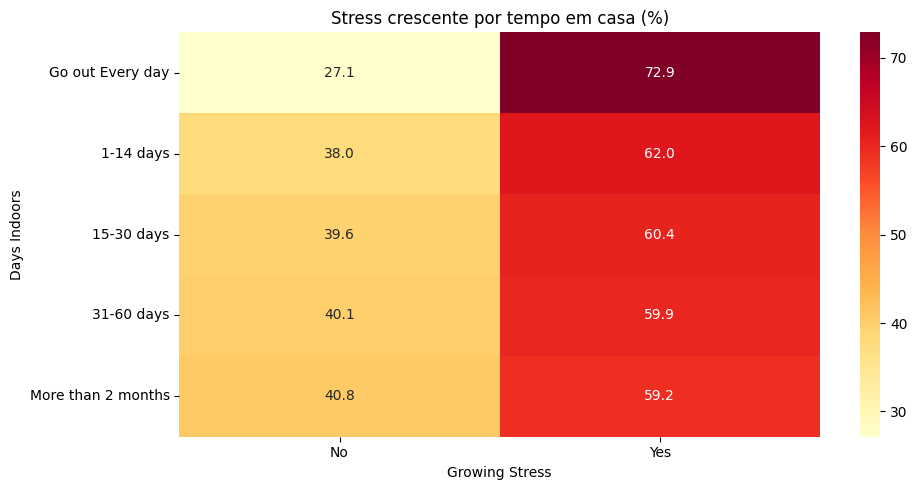

In [29]:
days_order = ['Go out Every day', '1-14 days', '15-30 days', '31-60 days', 'More than 2 months']
stress_order = ['No', 'Yes']

plot_df = df.copy()
plot_df['Days_Indoors'] = pd.Categorical(plot_df['Days_Indoors'], categories=days_order, ordered=True)
plot_df['Growing_Stress'] = pd.Categorical(plot_df['Growing_Stress'], categories=stress_order, ordered=True)

ct = pd.crosstab(plot_df['Days_Indoors'], plot_df['Growing_Stress'], normalize='index') * 100

plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Stress crescente por tempo em casa (%)')
plt.xlabel('Growing Stress')
plt.ylabel('Days Indoors')
plt.tight_layout()
plt.show()

<span style="font-size: 12px;">
<b>Quanto mais tempo em casa, maior tende a ser o nível de stress.</b><br>
- Quem sai todos os dias apresenta um nível consíderável de stress<br>
- Quem fica muito tempo em casa mostra um nível maior de stress<br>
- Podemos deduzir que o equilibrio é o melhor cenário.
</span>

### **Pipeline**

###### Nesta etapa, faremos Pipeline que prepara os dados (trata nulos, codifica variáveis categóricas).

In [30]:
# Separação entre X e y
X = df.drop(columns=['treatment'])
y = df['treatment'].map({'No': 0, 'Yes': 1})

# Grupos de colunas
cols_binary = ['family_history', 'Coping_Struggles','Growing_Stress',
               'Changes_Habits', 'Mental_Health_History',
               'Work_Interest', 'Social_Weakness']

cols_binary_gender = ['Gender']

cols_ordinal_days = ['Days_Indoors']
cols_ordinal_mood = ['Mood_Swings']
cols_ordinal_care = ['care_options']


# Pipelines

# Binárias sem nulos
binary_pipe = OrdinalEncoder(
    categories=[['No', 'Yes']] * len(cols_binary)
)

# Gênero
gender_pipe = OrdinalEncoder(
    categories=[['Male', 'Female']] * len(cols_binary_gender)
    )


# Ordinal - Days_Indoors
days_pipe = OrdinalEncoder(categories=[[
    'Go out Every day', '1-14 days', '15-30 days', '31-60 days', 'More than 2 months'
]])

# Ordinal - Mood_Swings
mood_pipe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])


preprocessor_onehot = ColumnTransformer(
    transformers=[
        ('binary',  binary_pipe,          cols_binary),
        ('gender',  gender_pipe,          cols_binary_gender),
        ('days',    days_pipe,            cols_ordinal_days),
        ('mood',    mood_pipe,            cols_ordinal_mood),
    ],
    remainder='drop'
)


In [31]:
#Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

### **Dicionário de pipelines**


In [32]:
pipelines = {
    "knn": Pipeline([
        ('prep', preprocessor_onehot),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', KNeighborsClassifier())
    ]),

    "svc": Pipeline([
        ('prep', preprocessor_onehot),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', SVC(kernel='linear', probability=True, random_state=42))
    ]),

    "logreg": Pipeline([
        ('prep', preprocessor_onehot),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "rf": Pipeline([
        ('prep', preprocessor_onehot),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=3,
            random_state=42,
            class_weight='balanced'
        ))
    ]),
}

### **KNN**

###### Testando o modelo KNeighborsClassifier (KNN).

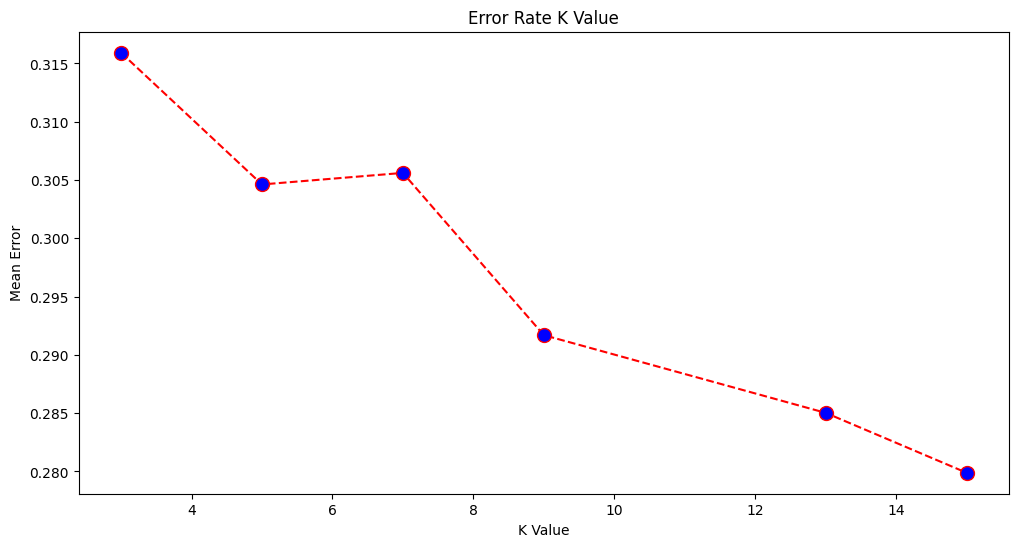

In [33]:
error = []
k_values = [3, 5, 7, 9, 13, 15]

for i in k_values:
    pipe = clone(pipelines["knn"])

    pipe.set_params(
        model__n_neighbors=i,
        model__n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    pred_i = pipe.predict(X_test)

    error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(12, 6))
plt.plot(k_values, error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')
plt.show()

<span style="font-size: 12px;">
- O erro tende a diminuir conforme o K aumenta<br>
- A melhor opção de K é 15
</span>

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid_knnn = {
    'model__n_neighbors': [3, 5, 7, 9, 13, 15],
    'model__metric': ['euclidean', 'manhattan', 'cosine'],
    'model__weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    pipelines["knn"],
    param_grid=param_grid_knnn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

pred_i = grid.predict(X_test)
knn_params = grid.best_params_

print('KNN', knn_params)
print('Acurácia', accuracy_score(y_test, pred_i))


c:\Python\F1Challenge\app\venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.67520314 0.67520314 0.69024003 0.69024003 0.69328477 0.69328477
 0.70275521 0.70275521 0.71306622 0.7130849  0.71911833 0.71900626
 0.67520314 0.67520314 0.69024003 0.69024003 0.69328477 0.69328477
 0.70275521 0.70275521 0.71301018 0.7130849  0.71902494 0.71900626
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan]
  warnings.warn(


KNN {'model__metric': 'euclidean', 'model__n_neighbors': 15, 'model__weights': 'uniform'}
Acurácia 0.7201135684399282


<span style="font-size: 12px;">
Utilizamos a técnica do GridSearchCV para ver os melhores hiperparâmetros para o modelo KNN e confirmamos que o melhor valor do k é 15
</span>

<Figure size 600x500 with 0 Axes>

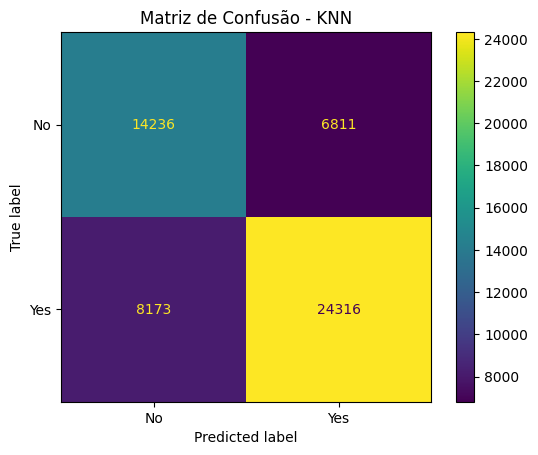

In [35]:
modelo_classificador = clone(pipelines["knn"])

modelo_classificador.set_params(
    model__n_neighbors=15,
    model__metric='euclidean',
    model__weights='uniform',
    model__n_jobs=-1
)

modelo_classificador.fit(X_train, y_train)

y_predito = modelo_classificador.predict(X_test)

matriz_confusao = confusion_matrix(
    y_true=y_test,
    y_pred=y_predito
)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=['No', 'Yes']
)
disp.plot(values_format='d')
plt.title("Matriz de Confusão - KNN")
plt.show()

<span style="font-size: 12px;">
<b>Modelo com desempenho baixo (~65%).</b><br>
- Erros altos e equilibrados entre classes<br>
KNN apresentou alto erro e baixa performance, além de elevado custo computacional, não sendo adequado para este dataset.
</span>

In [36]:
print(classification_report(y_test, y_predito))

              precision    recall  f1-score   support

           0       0.64      0.68      0.66     21047
           1       0.78      0.75      0.76     32489

    accuracy                           0.72     53536
   macro avg       0.71      0.71      0.71     53536
weighted avg       0.72      0.72      0.72     53536



In [ ]:
# Para reduzir o tempo de execução usaremos uma parte menor do dataset
n = min(10000, len(X_train))

X_small = X_train.sample(n=n, random_state=42)
y_small = y_train.loc[X_small.index]

### **Testando vários tipos de algoritmos de classificação**

##### **Função: AplicaValidacaoCruzada**

##### **Objetivo:**
###### Essa função aplica **validação cruzada (Cross-Validation)** para comparar o desempenho de diferentes modelos de machine learning e identificar o melhor.

---

##### **Modelos utilizados:**
###### - **SVC (Support Vector Classifier)** → classifica os dados encontrando o melhor hiperplano que maximiza a separação entre as classes  
###### - **Logistic Regression** → modelo linear que estima probabilidades e separa classes usando uma função logística  
###### - **Random Forest Classifier** → conjunto de árvores de decisão que combina múltiplas previsões para melhorar a precisão e reduzir overfitting

---

##### **Validação Cruzada (KFold):**
###### KFold(n_splits=10) → divide os dados em 10 partes

---

##### **Função retorna melhor modelo**

In [ ]:
def AplicaValidacaoCruzada(x_axis, y_axis, pipelines):

  kfold = KFold(n_splits=10, shuffle=True, random_state=42)

  x = x_axis
  y = y_axis

  metricas = {
      'accuracy': 'accuracy',
      'precision': 'precision',
      'recall': 'recall',
      'f1': 'f1'
      }

  resultados = {}

  for nome, pipe in pipelines.items():

    scores = cross_validate(
        pipe,
        x,
        y,
        cv=kfold,
        scoring=metricas,
        n_jobs=-1
    )

    resultados[nome] = {
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean()
        }

  # Melhor modelo por Recall
  melhorModelo = max(resultados, key=lambda nome: resultados[nome]['recall'])

  print(f"Validação cruzada:\n")

  for nome, info in resultados.items():
    print(f"{nome}:")
    print(f"  Accuracy : {info['accuracy']:.4f}")
    print(f"  Precision: {info['precision']:.4f}")
    print(f"  Recall   : {info['recall']:.4f}")
    print(f"  F1-score : {info['f1']:.4f}")
    print()

  print(f"Melhor modelo (Recall): {melhorModelo} → {resultados[melhorModelo]['recall']:.4f}")

  return melhorModelo

In [ ]:
melhorModelo = AplicaValidacaoCruzada(X_small, y_small, pipelines)

Validação cruzada:

knn:
  Accuracy : 0.6986
  Precision: 0.7610
  Recall   : 0.7326
  F1-score : 0.7463

svc:
  Accuracy : 0.6680
  Precision: 0.7798
  Recall   : 0.6292
  F1-score : 0.6960

logreg:
  Accuracy : 0.6755
  Precision: 0.7132
  Recall   : 0.7760
  F1-score : 0.7431

rf:
  Accuracy : 0.6688
  Precision: 0.7901
  Recall   : 0.6157
  F1-score : 0.6921

Melhor modelo (Recall): logreg → 0.7760


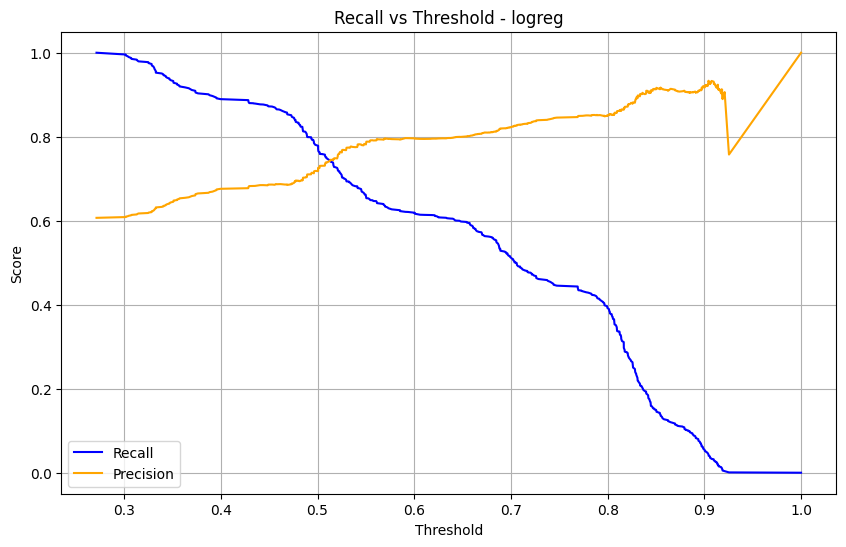

In [ ]:
# Clonar pipeline do melhor modelo
best_pipe = clone(pipelines[melhorModelo])

# Treinar no treino
best_pipe.fit(X_train, y_train)

# Probabilidades do melhor modelo
y_prob = best_pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# thresholds tem tamanho menor → ajustar
thresholds = np.append(thresholds, 1)

plt.figure(figsize=(10,6))

plt.plot(thresholds, recall, label='Recall', color='blue')
plt.plot(thresholds, precision, label='Precision', color='orange')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Recall vs Threshold - {melhorModelo}')
plt.legend()
plt.grid()

plt.show()

<span style="font-size: 12px;">
<b>O gráfico mostra que, com um threshold baixo, o modelo encontra quase todos os casos, mas comete mais erros. À medida que o threshold aumenta, ele erra menos, porém deixa de identificar vários casos.</b>

Threshold é o valor que define a partir de qual probabilidade o modelo classifica como 1 (positivo) ou 0 (negativo). É como uma “nota mínima” para decidir.
<br>
</span>

<span style="font-size: 12px;">
<b>Conclusão.</b>

Os modelos tiveram um desempenho razoável e conseguiram identificar alguns padrões importantes, mas ainda dá pra melhorar, seja ajustando melhor os parâmetros, tratando de outra forma as linhas que foram removidas ou até testando outros modelos. Mesmo assim, já dá pra notar, através da análise exploratória, que os fatores emocionais e o histórico de saúde mental têm um peso muito maior na decisão de buscar tratamento do que outras características mais gerais.
<br>
</span>

